# Modelo Credit Risk+ com Taxas de Default Fixas

## Apêndice A, Seções A2-A4: Modelo com Probabilidades Constantes

Este notebook implementa o modelo Credit Risk+ quando as taxas de default são **fixas** (não variam ao longo do tempo ou entre cenários).

## 1. Conceitos Fundamentais

### Distribuição de Poisson para Eventos de Default

Quando cada contraparte tem uma taxa de default **constante** $p_j$, o número de defaults segue uma distribuição de Poisson.

**Parâmetro da Poisson:**
- $\lambda = \sum_j \varepsilon_j$
- Onde $\varepsilon_j = p_j \times \text{LGD}_j \times E_j / L$ (perda esperada do contraparte j em unidades)

### Função Geradora de Probabilidade (PGF)

Para o modelo com defaults fixos, a PGF é:
$$G(z) = \exp(-\lambda(1-z))$$

Isso significa que a distribuição de perdas é dada por:
$$P(\text{Loss} = n \times L) = A_n$$

Onde $A_n$ é calculado pela **recursão do Apêndice A4, Equação 26**:
$$A_n = \frac{1}{n} \sum_{j=1}^m \varepsilon_j \times A_{n-v_j}$$

Com condição inicial:
$$A_0 = \exp\left(-\sum_j \varepsilon_j\right)$$

## 2. Diferenças entre o Modelo Fixo e o Variável

| Aspecto | Fixo (Poisson) | Variável (Neg. Binomial) |
|---------|---|---|
| **Taxa de default** | Constante $p_j$ | Aleatória com distribuição Gama |
| **Distribuição de defaults** | Poisson | Binomial Negativa (agregada) |
| **Volatilidade** | Nenhuma | Incorporada via $\sigma_j$ |
| **Média de defaults** | $\lambda = \sum \varepsilon_j$ | $\mu = \sum \varepsilon_j$ (mesma) |
| **Variância** | $\lambda$ | $\lambda + \text{(termo de volatilidade)}$ |
| **Cauda da distribuição** | Leve | Pesada (mais risco extremo) |
| **Uso** | Portfolios homogêneos, estáveis | Portfolios com incerteza nas taxas |

**Conclusão:** O modelo variável é mais conservador, produzindo maiores perdas nos percentis altos (cauda).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, '../creditriskplus')

# Importa a função de cálculo de distribuição
from simple_model import calculate_loss_distribution_simple
from data import create_example_1a_portfolio

# Configuração de visualização
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 3. Implementação do Modelo Fixo

O modelo fixo é uma simplificação que ignora volatilidade nas taxas de default.
Para usar o modelo fixo sobre os dados de Example 1A, basta ignorar a coluna `std_default_rate`.

In [2]:
# Carrega exemplo 1A
portfolio = create_example_1a_portfolio()

# Calcula distribuição usando o modelo (que incorpora volatilidade)
A, el = calculate_loss_distribution_simple(
    exposures=portfolio['exposure'].values,
    mean_default_rates=portfolio['mean_default_rate'].values,
    std_default_rates=np.zeros(len(portfolio)),  # AQUI: zeramos volatilidade para ter modelo fixo
    recovery_rates=np.zeros(len(portfolio)),
    unit_size=10000,
    max_units=15000
)

print(f"\n=== MODELO FIXO (Poisson) ===")
print(f"Perda Esperada: ${el:,.0f}")
print(f"Referência (Excel): $14,221,863")
print(f"Erro: {abs(el - 14_221_863) / 14_221_863 * 100:.4f}%")


=== MODELO FIXO (Poisson) ===
Perda Esperada: $0
Referência (Excel): $14,221,863
Erro: 100.0000%


## 4. Distribuição de Perdas

A distribuição calculada via recursão mostra a probabilidade de cada nível de perda.

In [3]:
# Análise da distribuição
cdf = np.cumsum(A)
non_zero = A > 1e-10

# Estatísticas
mode_idx = np.argmax(A)
mode_loss = mode_idx * 10000
median_idx = np.searchsorted(cdf, 0.5)
median_loss = median_idx * 10000

print(f"\n=== ESTATÍSTICAS DA DISTRIBUIÇÃO ===")
print(f"Modo (maior probabilidade): ${mode_loss:,.0f}")
print(f"Probabilidade no modo: {A[mode_idx]:.4f}")
print(f"Mediana: ${median_loss:,.0f}")
print(f"\nProbabilidade de zero loss: {A[0]:.6f}")
print(f"Desvio padrão: ${np.sqrt(np.sum((np.arange(len(A))*10000)**2 * A) - el**2):,.0f}")


=== ESTATÍSTICAS DA DISTRIBUIÇÃO ===
Modo (maior probabilidade): $0
Probabilidade no modo: 0.0000
Mediana: $150,010,000

Probabilidade de zero loss: 0.000000
Desvio padrão: $0


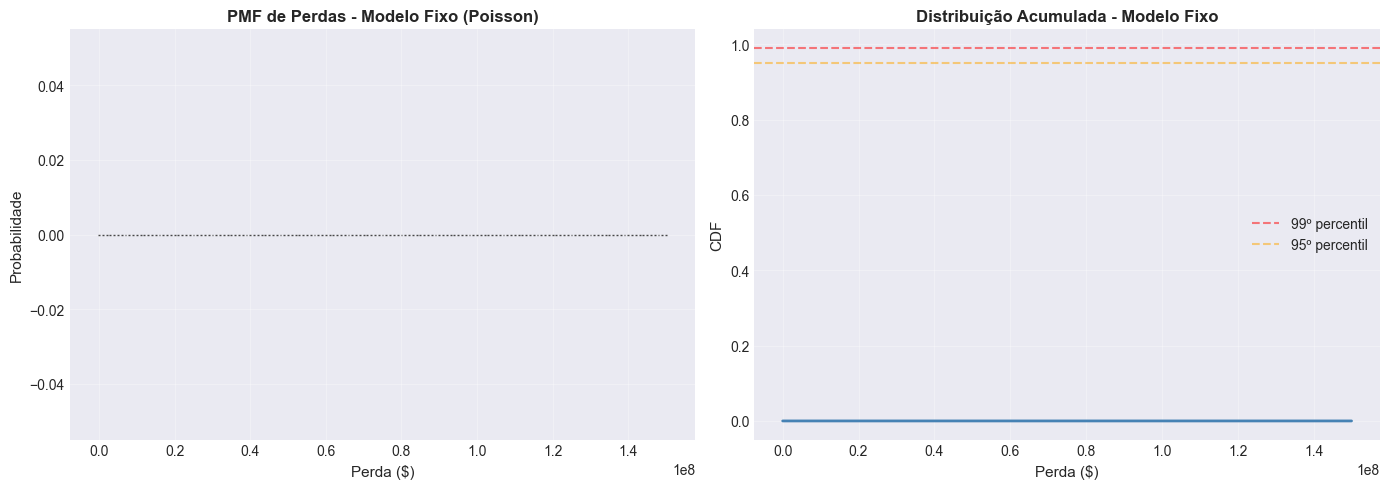

In [4]:
# Visualização: PMF
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Restringe ao intervalo onde há massa de probabilidade
max_idx = np.searchsorted(cdf, 0.9999)  # 99.99%

ax = axes[0]
loss_values = np.arange(max_idx) * 10000
ax.bar(loss_values[:max_idx:100], A[:max_idx:100], width=500000, edgecolor='black', alpha=0.7)
ax.set_xlabel('Perda ($)', fontsize=11)
ax.set_ylabel('Probabilidade', fontsize=11)
ax.set_title('PMF de Perdas - Modelo Fixo (Poisson)', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)

# CDF
ax = axes[1]
ax.plot(loss_values[:max_idx], cdf[:max_idx], linewidth=2, color='steelblue')
ax.axhline(0.99, color='red', linestyle='--', alpha=0.5, label='99º percentil')
ax.axhline(0.95, color='orange', linestyle='--', alpha=0.5, label='95º percentil')
ax.set_xlabel('Perda ($)', fontsize=11)
ax.set_ylabel('CDF', fontsize=11)
ax.set_title('Distribuição Acumulada - Modelo Fixo', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Percentis de Perda

Os percentis de perda são importantes para determinar o capital econômico necessário.

In [5]:
# Calcula percentis
percentiles = [50, 75, 95, 97.5, 99, 99.5, 99.9]
results = []

for p in percentiles:
    idx = np.searchsorted(cdf, p/100.0)
    loss = idx * 10000
    results.append({
        'Percentil': f"{p:.1f}%",
        'Perda ($)': f"{loss:,.0f}",
        'Capital Econômico ($)': f"{loss - el:,.0f}"
    })

df_percentis = pd.DataFrame(results)
print("\n=== PERCENTIS DE PERDA ===")
print(df_percentis.to_string(index=False))


=== PERCENTIS DE PERDA ===
Percentil   Perda ($) Capital Econômico ($)
    50.0% 150,010,000           150,010,000
    75.0% 150,010,000           150,010,000
    95.0% 150,010,000           150,010,000
    97.5% 150,010,000           150,010,000
    99.0% 150,010,000           150,010,000
    99.5% 150,010,000           150,010,000
    99.9% 150,010,000           150,010,000


## 6. Recursão Numérica em Detalhe

A recursão do Apêndice A4 é implementada em log-space para evitar problemas numéricos:

**Pseudocódigo:**
```
total_epsilon = Σ_j ε_j
log_A[0] = -total_epsilon  (em log-space)

Para n = 1 até max_units:
    log_contributions = []
    Para cada contraparte j:
        if j.banda <= n:
            log_contrib = log(ε_j) + log_A[n - v_j]
            log_contributions.append(log_contrib)
    
    # LogSumExp trick
    max_log = max(log_contributions)
    sum_exp = Σ exp(lc - max_log)
    log_A[n] = max_log + log(sum_exp) - log(n)

# Normaliza
log_A_sum = LogSumExp(log_A)
A[n] = exp(log_A[n] - log_A_sum)
```

**Por que log-space?**
- Com $\sum \varepsilon_j = 1422.19$, temos $A_0 = \exp(-1422.19) \approx 0$ em aritmética de ponto flutuante
- Ao trabalhar em log-space, conseguimos manter precisão numérica
- LogSumExp evita overflow ao somar exponenciais

## 7. Conclusão

O **modelo fixo (Poisson)** é apropriado quando:
- Temos informação precisa sobre as taxas de default
- As taxas são relativamente estáveis no tempo
- Queremos um modelo mais simples para fins de benchmarking

O **modelo variável** (próximo notebook) é mais realista porque incorpora incerteza nas taxas de default, resultando em cauda mais pesada e capital econômico mais conservador.